# GraphRAG for Alzheimer's Disease Literature -- Pipeline, Retrieval & Evaluation

This notebook is the **GraphRAG arm** of a head-to-head comparison: build a knowledge
graph out of biomedical literature, answer questions by retrieving *structured graph
context* instead of raw text, and then score the whole thing against a held-out
evaluation set. The companion notebook builds the **VectorRAG arm** (dense chunk
retrieval, no graph), so the two can be compared on identical questions with identical
metrics.

## Why GraphRAG for a biomedical corpus?

Alzheimer's research is full of questions that don't live inside a single sentence --
"how does APOE genotype interact with sex to affect risk?", "how do microglia connect
the amyloid hypothesis to the neuroinflammation hypothesis?" -- these require
**connecting facts** that may be scattered across different papers. A knowledge graph
of `(entity) --[relation]--> (entity)` triples makes that connective structure
explicit and directly retrievable, which is exactly what GraphRAG is built to exploit.

## Pipeline overview -- 9 stages

| Stage | What happens |
|---|---|
| **1. Environment Setup** | Load Qwen2.5-3B-Instruct (generation), biomedical NER, SapBERT (embeddings), connect to Neo4j |
| **2. Data Loading & Chunking** | Load Alzheimer's abstracts, split into overlapping word chunks |
| **3. Entity Extraction & Normalization** | NER + MeSH terms -> cleaned, deduplicated entity list per chunk |
| **4. Relation Extraction** | LLM extracts `(head, relation, tail)` triples per chunk |
| **5. Knowledge Graph Construction** | Write papers, chunks, entities & relations into Neo4j |
| **6. Graph Visualization** | Render the extracted graph with NetworkX |
| **7. Retrieval Pipeline** | Question -> similar entities -> local subgraph + supporting chunks |
| **8. GraphRAG Question Answering** | Graph context -> prompt -> LLM answer |
| **9. Formal Evaluation** | Score 30 held-out questions on answer quality *and* retrieval quality |

# Stage 1: Environment Setup

## 1.1 Install Dependencies

Installs the core stack: `transformers` / `accelerate` / `bitsandbytes` for the LLM,
`sentence-transformers` for embeddings, `neo4j` for the graph database driver,
`networkx` for graph visualization, `scikit-learn` for similarity math, and
`evaluate` / `bert-score` / `rouge-score` for the evaluation section at the end.


In [2]:
!pip -q install transformers accelerate bitsandbytes sentence-transformers

!pip -q install neo4j

!pip -q install networkx

!pip -q install scikit-learn

!pip -q install datasets

!pip -q install evaluate

!pip -q install bert-score rouge-score

!pip -q install tqdm

!pip -q install pandas numpy matplotlib

!pip -q install torch torchvision torchaudio

!pip -q install optimum

!pip -q install huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 13.6 MB/s eta 0:00:00


In [1]:
import os
import re
import json
import time
import random
import warnings

import numpy as np
import pandas as pd

from tqdm import tqdm

warnings.filterwarnings("ignore")

In [2]:
import torch

print("Torch :", torch.__version__)

print("CUDA :", torch.cuda.is_available())

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

Torch : 2.11.0+cu128
CUDA : True
Tesla T4


## 1.2 Load the Models

Three models power this pipeline:

- **Qwen2.5-3B-Instruct** -- causal LLM used for both relation extraction (passage +
  entities -> structured triples) and final answer generation. Loaded in fp16 with
  `device_map="auto"`.
- **`d4data/biomedical-ner-all`** -- token-classification model for biomedical NER,
  used to pull candidate entities (drugs, genes, diseases, etc.) out of chunk text.
- **SapBERT** (`cambridgeltl/SapBERT-from-PubMedBERT-fulltext`) -- biomedical sentence
  embedding model, used for entity deduplication and for matching a question to graph
  entities at retrieval time.


In [3]:
from transformers import AutoTokenizer
from transformers import AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Qwen Loaded")



[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen Loaded


In [4]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

print("Generator Ready!")

Generator Ready!


In [5]:
from transformers import pipeline

ner = pipeline(
    "token-classification",
    model="d4data/biomedical-ner-all",
    aggregation_strategy="simple",
    device=0
)

print("Biomedical NER Loaded")

config.json:   0%|          | 0.00/5.00k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  266MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Biomedical NER Loaded


In [6]:
from sentence_transformers import SentenceTransformer

retriever_model = SentenceTransformer(
    "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
)

print("SapBERT Loaded")

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

SapBERT Loaded


## 1.3 Connect to Neo4j

Opens a driver connection to the Neo4j Aura instance that will store the knowledge graph.


In [ ]:
from neo4j import GraphDatabase

URI = "NEO4J_URI"

USERNAME = "NEO4J_USERNAME"

PASSWORD = "NEO4J_PASSWORD"

driver = GraphDatabase.driver(
    URI,
    auth=(USERNAME, PASSWORD)
)

print("Neo4j Connected")

Neo4j Connected


## 1.4 Environment Summary

Quick sanity check confirming which LLM, NER model, embedding model, and database connection are active.


In [8]:
print("="*50)

print("Qwen        :", MODEL_NAME)

print("NER Model   : d4data/biomedical-ner-all")

print("Embedding   : SapBERT")

print("Neo4j       : Connected")

print("="*50)

Qwen        : Qwen/Qwen2.5-3B-Instruct
NER Model   : d4data/biomedical-ner-all
Embedding   : SapBERT
Neo4j       : Connected


# Stage 2: Data Loading & Chunking

## 2.1 Load and Prepare the Dataset

Mounts Google Drive, locates the raw Alzheimer's abstract JSON records and the
evaluation question set, and reshapes each document into a `{title, abstract}` text
record ready for chunking.


In [9]:
import os
import json
import re
from tqdm import tqdm

## 2.2 Mount Google Drive


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2.3 Define Paths

Paths to the folder of per-article JSON files and to the evaluation question set.


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/ALZ/Dataset"

EVAL_PATH = "/content/drive/MyDrive/ALZ/eval_dataset.json"

## 2.4 Inspect the Dataset Directory


In [12]:
import os

json_files = sorted([
    f for f in os.listdir(DATASET_PATH)
    if f.endswith(".json")
])

print("Total JSON files:", len(json_files))
print()

print("First 5 files:")
for f in json_files[:5]:
    print(f)

Total JSON files: 33

First 5 files:
_pubmed_manifest.json
_wikipedia_manifest.json
pubmed_12672860_treatment_memantine.json
pubmed_21371747_pathology_tau.json
pubmed_23276979_genetics_familial.json


## 2.5 Load Documents (initial pass)

Superseded by the more careful loader in the next cell (handles manifest files and both dict/list-shaped JSON).


In [13]:
import json
from tqdm import tqdm

documents = []

for file in tqdm(json_files):

    with open(
        os.path.join(DATASET_PATH, file),
        "r",
        encoding="utf-8"
    ) as f:

        data = json.load(f)

    documents.append({
        "filename": file,
        "content": data
    })

print("Loaded", len(documents), "documents")

100%|██████████| 33/33 [00:21<00:00,  1.54it/s]

Loaded 33 documents


## 2.6 Load Documents (final loader)

Skips manifest files (prefixed `_`), normalizes both dict- and list-shaped JSON into a flat `documents` list, tagging each with its source filename.


In [14]:
# ==========================================
# LOAD DOCUMENTS
# ==========================================

import glob
import os
import json

documents = []

json_files = sorted(glob.glob(os.path.join(DATASET_PATH, "*.json")))

for file in json_files:

    filename = os.path.basename(file)

    # Skip manifest files
    if filename.startswith("_"):
        continue

    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict):

        data["source_file"] = filename
        documents.append(data)

    elif isinstance(data, list):

        for item in data:
            item["source_file"] = filename
            documents.append(item)

print(f"Loaded {len(documents)} documents.")

Loaded 31 documents.


In [15]:
print(type(documents[0]))

print(documents[0].keys())

<class 'dict'>
dict_keys(['pmid', 'title', 'abstract', 'authors', 'journal', 'year', 'mesh_terms', 'doi', 'url', 'subtopic', 'source_type', 'article_id', 'source_file'])


## 2.7 Load Evaluation Questions

Loads the 30-question held-out set used both interactively and in the formal evaluation later.


In [16]:
with open(EVAL_PATH, "r", encoding="utf-8") as f:

    eval_dataset = json.load(f)

questions = eval_dataset["questions"]

print(f"Loaded {len(questions)} evaluation questions.")

Loaded 30 evaluation questions.


## 2.8 Build Processed Documents

Combines title + abstract into one text field, keeping metadata (PMID, MeSH terms, year, journal) needed downstream.


In [17]:
processed_docs = []

for idx, doc in enumerate(documents):

    title = doc.get("title", "").strip()

    abstract = doc.get("abstract", "").strip()

    text = f"{title}\n\n{abstract}"

    processed_docs.append({

        "doc_id": idx,

        "pmid": doc.get("pmid"),

        "title": title,

        "text": text,

        "mesh_terms": doc.get("mesh_terms", []),

        "year": doc.get("year"),

        "journal": doc.get("journal"),

        "source_file": doc.get("source_file")

    })

print("Documents:", len(processed_docs))

Documents: 31


In [18]:
processed_docs[0]

{'doc_id': 0,
 'pmid': '12672860',
 'title': "Memantine in moderate-to-severe Alzheimer's disease.",
 'text': "Memantine in moderate-to-severe Alzheimer's disease.\n\nBACKGROUND: Overstimulation of the N-methyl-D-aspartate (NMDA) receptor by glutamate is implicated in neurodegenerative disorders. Accordingly, we investigated memantine, an NMDA antagonist, for the treatment of Alzheimer's disease.\nMETHODS: Patients with moderate-to-severe Alzheimer's disease were randomly assigned to receive placebo or 20 mg of memantine daily for 28 weeks. The primary efficacy variables were the Clinician's Interview-Based Impression of Change Plus Caregiver Input (CIBIC-Plus) and the Alzheimer's Disease Cooperative Study Activities of Daily Living Inventory modified for severe dementia (ADCS-ADLsev). The secondary efficacy end points included the Severe Impairment Battery and other measures of cognition, function, and behavior. Treatment differences between base line and the end point were assessed. 

## 2.9 Text Chunking

Splits each document into overlapping 300-word chunks (50-word overlap) so each unit fits comfortably in the LLM's context window, while overlap avoids splitting a relevant sentence across chunk boundaries. Chunks under 40 words are dropped.


In [19]:


def chunk_text(text,
               chunk_size=300,
               overlap=50):

    words = text.split()

    chunks = []

    start = 0

    while start < len(words):

        end = start + chunk_size

        chunk = " ".join(words[start:end])

        chunks.append(chunk)

        start += chunk_size - overlap

    return chunks

In [20]:
processed_chunks = []

for doc in processed_docs:

    chunks = chunk_text(doc["text"])

    for cid, chunk in enumerate(chunks):

        if len(chunk.split()) < 40:
            continue

        processed_chunks.append({

            "doc_id": doc["doc_id"],

            "chunk_id": cid,

            "pmid": doc["pmid"],

            "title": doc["title"],

            "mesh_terms": doc["mesh_terms"],

            "text": chunk

        })

print("Total Chunks:", len(processed_chunks))

Total Chunks: 22


In [21]:
print(processed_chunks[0]["title"])

print()

print(processed_chunks[0]["text"])

Memantine in moderate-to-severe Alzheimer's disease.

Memantine in moderate-to-severe Alzheimer's disease. BACKGROUND: Overstimulation of the N-methyl-D-aspartate (NMDA) receptor by glutamate is implicated in neurodegenerative disorders. Accordingly, we investigated memantine, an NMDA antagonist, for the treatment of Alzheimer's disease. METHODS: Patients with moderate-to-severe Alzheimer's disease were randomly assigned to receive placebo or 20 mg of memantine daily for 28 weeks. The primary efficacy variables were the Clinician's Interview-Based Impression of Change Plus Caregiver Input (CIBIC-Plus) and the Alzheimer's Disease Cooperative Study Activities of Daily Living Inventory modified for severe dementia (ADCS-ADLsev). The secondary efficacy end points included the Severe Impairment Battery and other measures of cognition, function, and behavior. Treatment differences between base line and the end point were assessed. Missing observations were imputed by using the most recent pr

## 2.10 Save Chunks

Persists `processed_chunks.json`.


In [22]:
with open("/content/processed_chunks.json","w") as f:

    json.dump(processed_chunks,f,indent=2)

print("Saved processed_chunks.json")

Saved processed_chunks.json


# Stage 3: Entity Extraction & Normalization

## 3.1 Overview

Extracts candidate entities from two complementary sources -- **biomedical NER** on
raw text, and the **MeSH terms** already curated for each article -- merges them,
filters against a stopword list of overly generic clinical terms, and deduplicates
near-identical mentions using SapBERT embedding similarity (0.90 cosine threshold).


In [23]:
import re

def extract_entities(text):

    predictions = ner(text)

    entities = []

    for pred in predictions:

        entity = pred["word"]

        # Merge wordpiece tokens
        entity = entity.replace("##", "")

        # Normalize spaces
        entity = re.sub(r"\s+", " ", entity).strip()

        # Skip short/noisy entities
        if len(entity) < 3:
            continue

        if entity.isdigit():
            continue

        entities.append(entity)

    return list(set(entities))

## 3.2 Stopword Filtering

Generic clinical words ("patient", "treatment", "mild"...) too vague to be useful graph entities.


In [24]:
STOPWORDS = {

    "better",
    "daily",
    "living",
    "place",
    "patient",
    "patients",
    "study",
    "group",
    "control",
    "year",
    "years",
    "male",
    "female",
    "treatment",
    "treated",
    "therapy",
    "severe",
    "moderate",
    "mild",
    "high",
    "low",
    "normal",
    "healthy",
    "disease",
    "week",
    "weeks",
    "month",
    "months",
    "mg",
    "ml"

}

## 3.3 Clean Entities

Strips wordpiece artifacts, collapses whitespace, drops short/numeric noise and stopwords.


In [25]:
def clean_entities(entity_list):

    cleaned = []

    for entity in entity_list:

        entity = entity.strip()

        entity = entity.replace("##", "")

        entity = re.sub(r"\s+", " ", entity)

        entity = entity.strip()

        if len(entity) < 3:
            continue

        if entity.lower() in STOPWORDS:
            continue

        if entity.isdigit():
            continue

        cleaned.append(entity)

    return list(set(cleaned))

## 3.4 Extract MeSH Entities

Pulls each document's curated MeSH term list into a clean entity set.


In [26]:
def get_mesh_entities(mesh_terms):

    entities = []

    if isinstance(mesh_terms, list):

        for item in mesh_terms:

            item = str(item).strip()

            if len(item):

                entities.append(item)

    return list(set(entities))

## 3.5 Combine NER + MeSH Entities

Merges both entity sources for a chunk.


In [27]:
def collect_entities(chunk):

    ner_entities = extract_entities(

        chunk["text"]

    )

    ner_entities = clean_entities(

        ner_entities

    )

    mesh_entities = get_mesh_entities(

        chunk["mesh_terms"]

    )

    entities = list(

        set(

            mesh_entities +

            ner_entities

        )

    )

    return entities

## 3.6 Embed Entities for Deduplication

Encodes entity strings with SapBERT for similarity-based dedup.


In [28]:
def embed_entities(entity_list):

    embeddings = retriever_model.encode(

        entity_list,

        normalize_embeddings=True,

        show_progress_bar=False

    )

    return embeddings

## 3.7 Normalize / Deduplicate Similar Entities

Greedily keeps one representative per cluster of entities whose cosine similarity exceeds 0.90.


In [29]:
def normalize_entities(entity_list,
                       threshold=0.90):

    if len(entity_list) == 0:
        return []

    embeddings = embed_entities(

        entity_list

    )

    keep = []

    removed = set()

    for i in range(len(entity_list)):

        if i in removed:
            continue

        keep.append(entity_list[i])

        similarity = cosine_similarity(

            [embeddings[i]],

            embeddings

        )[0]

        for j, score in enumerate(similarity):

            if i == j:
                continue

            if score >= threshold:

                removed.add(j)

    return keep

## 3.8 Build Final Entity List per Chunk

Runs collect -> normalize -> sort for a single chunk.


In [30]:
def build_entity_list(chunk):

    entities = collect_entities(chunk)

    entities = normalize_entities(

        entities,

        threshold=0.90

    )

    entities = sorted(

        list(

            set(entities)

        )

    )

    return entities

In [31]:
from sklearn.metrics.pairwise import cosine_similarity
sample_entities = build_entity_list(

    processed_chunks[0]

)

print("Entities Found:", len(sample_entities))

print()

for entity in sample_entities:

    print(entity)

Entities Found: 27

( nmda
. s. centers
20 mg
Activities of Daily Living
Aged
Behavior
Cognition
Disease Progression
Excitatory Amino Acid Antagonists
Female
Humans
Male
Memantine
Middle Aged
N-Methylaspartate
Severity of Illness Index
alzheimer ' s disease
d - aspartate
dementia
generative
glutamate
impairment
man
mantine
n - methyl -
receptor
two hundred fifty - two patients


## 3.9 Run Entity Extraction Over All Chunks

Builds the full `entity_dataset`.


In [32]:
entity_dataset = []

for chunk in tqdm(processed_chunks):

    entities = build_entity_list(

        chunk

    )

    entity_dataset.append({

        "doc_id": chunk["doc_id"],

        "chunk_id": chunk["chunk_id"],

        "pmid": chunk["pmid"],

        "title": chunk["title"],

        "text": chunk["text"],

        "entities": entities

    })

print()

print("Processed Chunks:", len(entity_dataset))

100%|██████████| 22/22 [00:01<00:00, 13.17it/s]


Processed Chunks: 22


## 3.10 Save Entity Dataset

Persists `entity_dataset.json`.


In [33]:
import json

with open(

    "/content/entity_dataset.json",

    "w"

) as f:

    json.dump(

        entity_dataset,

        f,

        indent=2

    )

print("Saved entity_dataset.json")

Saved entity_dataset.json


# Stage 4: Relation Extraction

## 4.1 Relation Extraction Prompt

Prompts Qwen2.5-3B-Instruct as a structured extractor: given a passage and its entity
list, output `HEAD | RELATION | TAIL` lines restricted to a fixed biomedical relation
vocabulary (`TREATS`, `CAUSES`, `ASSOCIATED_WITH`, `INHIBITS`, ...), using only
relations explicitly stated in the text.


In [34]:
RELATION_PROMPT = """
You are a biomedical knowledge graph expert.

Given:

1. A biomedical passage.
2. A list of biomedical entities.

Extract ONLY relations that are explicitly stated in the passage.

Use ONLY the provided entities.

Return one triple per line in exactly this format:

HEAD | RELATION | TAIL

Allowed relations:

TREATS
CAUSES
ASSOCIATED_WITH
INTERACTS_WITH
INHIBITS
ACTIVATES
EXPRESSED_IN
PART_OF
TARGETS
REGULATES
PREDISPOSES_TO

Do not explain anything.
Do not invent entities.
Return only triples.
"""

## 4.2 Relation Extraction Function

Formats the prompt as a chat message and runs generation.


In [35]:
def extract_relations(text, entities):

    if len(entities) < 2:
        return []

    entity_text = "\n".join(entities)

    prompt = f"""
{RELATION_PROMPT}

Passage:
{text}

Entities:
{entity_text}
"""

    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    chat = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        chat,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    ).to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0,
        do_sample=False
    )

    response = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return response

## 4.3 Parse Triples from LLM Output

Parses `HEAD | RELATION | TAIL` lines into structured triples.


In [36]:
def parse_triples(response):

    triples = []

    for line in response.split("\n"):

        line = line.strip()

        if "|" not in line:
            continue

        parts = [p.strip() for p in line.split("|")]

        if len(parts) != 3:
            continue

        head, relation, tail = parts

        if not head or not relation or not tail:
            continue

        triples.append({

            "head": head,

            "relation": relation.upper(),

            "tail": tail

        })

    return triples

In [37]:
sample = entity_dataset[0]

response = extract_relations(

    sample["text"],

    sample["entities"]

)

print(response)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user


You are a biomedical knowledge graph expert.

Given:

1. A biomedical passage.
2. A list of biomedical entities.

Extract ONLY relations that are explicitly stated in the passage.

Use ONLY the provided entities.

Return one triple per line in exactly this format:

HEAD | RELATION | TAIL

Allowed relations:

TREATS
CAUSES
ASSOCIATED_WITH
INTERACTS_WITH
INHIBITS
ACTIVATES
EXPRESSED_IN
PART_OF
TARGETS
REGULATES
PREDISPOSES_TO

Do not explain anything.
Do not invent entities.
Return only triples.


Passage:
Memantine in moderate-to-severe Alzheimer's disease. BACKGROUND: Overstimulation of the N-methyl-D-aspartate (NMDA) receptor by glutamate is implicated in neurodegenerative disorders. Accordingly, we investigated memantine, an NMDA antagonist, for the treatment of Alzheimer's disease. METHODS: Patients with moderate-to-severe Alzheimer's disease were randomly assigned to receive placebo or 20 mg of meman

In [38]:
triples = parse_triples(response)

print(triples)

[{'head': 'HEAD', 'relation': 'RELATION', 'tail': 'TAIL'}, {'head': 'Memantine', 'relation': 'TREATS', 'tail': "alzheimer 's disease"}, {'head': 'Memantine', 'relation': 'INHIBITS', 'tail': 'excitatory Amino Acid Antagonists'}, {'head': 'Memantine', 'relation': 'ASSOCIATED_WITH', 'tail': 'disease Progression'}]


## 4.4 Run Relation Extraction Over All Chunks

Builds the full `triple_dataset`.


In [39]:
from tqdm import tqdm

triple_dataset = []

for chunk in tqdm(entity_dataset):

    response = extract_relations(

        chunk["text"],

        chunk["entities"]

    )

    triples = parse_triples(response)

    triple_dataset.append({

        "doc_id": chunk["doc_id"],

        "chunk_id": chunk["chunk_id"],

        "pmid": chunk["pmid"],

        "title": chunk["title"],

        "triples": triples

    })

print("Processed:", len(triple_dataset))

100%|██████████| 22/22 [02:17<00:00,  6.27s/it]

Processed: 22


In [40]:
for triple in triple_dataset[0]["triples"]:

    print(triple)

{'head': 'HEAD', 'relation': 'RELATION', 'tail': 'TAIL'}
{'head': 'Memantine', 'relation': 'TREATS', 'tail': "alzheimer 's disease"}
{'head': 'Memantine', 'relation': 'INHIBITS', 'tail': 'excitatory Amino Acid Antagonists'}
{'head': 'Memantine', 'relation': 'ASSOCIATED_WITH', 'tail': 'disease Progression'}


## 4.5 Deduplicate Triples

Removes exact-duplicate `(head, relation, tail)` triples per document.


In [41]:
unique = {}

for doc in triple_dataset:

    cleaned = []

    for triple in doc["triples"]:

        key = (

            triple["head"],

            triple["relation"],

            triple["tail"]

        )

        if key not in unique:

            unique[key] = True

            cleaned.append(triple)

    doc["triples"] = cleaned

In [42]:
count = sum(

    len(doc["triples"])

    for doc in triple_dataset

)

print("Documents:", len(triple_dataset))

print("Total triples:", count)

Documents: 22
Total triples: 182


## 4.6 Save Triple Dataset

Persists `triple_dataset.json`.


In [43]:
import json

with open(

    "/content/triple_dataset.json",

    "w"

) as f:

    json.dump(

        triple_dataset,

        f,

        indent=2

    )

print("Saved triple_dataset.json")

Saved triple_dataset.json


# Stage 5: Knowledge Graph Construction

## 5.1 Reconnect to Neo4j

Writes the extracted entities and relations into Neo4j: `Paper`, `Chunk`, and `Entity`
nodes connected by `CONTAINS`, `MENTIONS`, and typed `RELATION` edges.


In [44]:

from neo4j import GraphDatabase

driver = GraphDatabase.driver(

    URI,

    auth=(USERNAME, PASSWORD)

)

print("Connected to Neo4j")

Connected to Neo4j


## 5.2 Clear Existing Graph


In [45]:
with driver.session() as session:

    session.run("MATCH (n) DETACH DELETE n")

print("Database cleared.")

Database cleared.


## 5.3 Create Schema Constraints

Uniqueness constraints on `Entity.name`, `Paper.pmid`, `Chunk.id`.


In [46]:
constraints = [

"""
CREATE CONSTRAINT entity_name IF NOT EXISTS
FOR (e:Entity)
REQUIRE e.name IS UNIQUE
""",

"""
CREATE CONSTRAINT paper_pmid IF NOT EXISTS
FOR (p:Paper)
REQUIRE p.pmid IS UNIQUE
""",

"""
CREATE CONSTRAINT chunk_id IF NOT EXISTS
FOR (c:Chunk)
REQUIRE c.id IS UNIQUE
"""

]

with driver.session() as session:

    for query in constraints:

        session.run(query)

print("Constraints Created")

Constraints Created


## 5.4 Assemble Graph Documents

Joins entity + triple datasets back together per chunk.


In [47]:
graph_documents = []

for entity_doc, triple_doc in zip(entity_dataset, triple_dataset):

    graph_documents.append({

        "doc_id": entity_doc["doc_id"],

        "chunk_id": entity_doc["chunk_id"],

        "pmid": entity_doc["pmid"],

        "title": entity_doc["title"],

        "text": entity_doc["text"],

        "entities": entity_doc["entities"],

        "triples": triple_doc["triples"]

    })

print(len(graph_documents))

22


## 5.5 Insert Paper and Chunk Nodes


In [48]:
with driver.session() as session:

    for doc in graph_documents:

        chunk = f'{doc["doc_id"]}_{doc["chunk_id"]}'

        session.run("""

        MERGE (p:Paper {pmid:$pmid})

        SET p.title=$title

        MERGE (c:Chunk {id:$chunk})

        SET c.text=$text

        MERGE (p)-[:CONTAINS]->(c)

        """,

        pmid=doc["pmid"],

        title=doc["title"],

        chunk=chunk,

        text=doc["text"])

## 5.6 Insert Entity Nodes and MENTIONS Relationships


In [49]:
with driver.session() as session:

    for doc in graph_documents:

        chunk = f'{doc["doc_id"]}_{doc["chunk_id"]}'

        for entity in doc["entities"]:

            session.run("""

            MERGE (e:Entity {name:$entity})

            MERGE (c:Chunk {id:$chunk})

            MERGE (p:Paper {pmid:$pmid})

            MERGE (c)-[:MENTIONS]->(e)

            MERGE (p)-[:MENTIONS]->(e)

            """,

            entity=entity,

            chunk=chunk,

            pmid=doc["pmid"])

## 5.7 Insert Extracted Relations

Writes triples as typed `RELATION` edges, tagged with source paper/chunk.


In [50]:
with driver.session() as session:

    for doc in graph_documents:

        chunk = f'{doc["doc_id"]}_{doc["chunk_id"]}'

        for triple in doc["triples"]:

            session.run("""

            MERGE (h:Entity {name:$head})

            MERGE (t:Entity {name:$tail})

            MERGE (h)-[r:RELATION]->(t)

            SET

            r.type=$relation,

            r.pmid=$pmid,

            r.paper=$paper,

            r.chunk=$chunk

            """,

            head=triple["head"],

            tail=triple["tail"],

            relation=triple["relation"],

            pmid=doc["pmid"],

            paper=doc["title"],

            chunk=chunk)

## 5.8 Verify Node Counts


In [51]:
with driver.session() as session:

    print(session.run("""

    MATCH (n)

    RETURN labels(n),count(*)

    """).data())

[{'labels(n)': ['Chunk'], 'count(*)': 22}, {'labels(n)': ['Paper'], 'count(*)': 20}, {'labels(n)': ['Entity'], 'count(*)': 348}]


## 5.9 Sample Relations

20 sample `(entity)-[relation]->(entity)` triples straight from the graph.


In [52]:
with driver.session() as session:

    result = session.run("""

    MATCH (a)-[r:RELATION]->(b)

    RETURN

    a.name,

    r.type,

    b.name

    LIMIT 20

    """)

    for row in result:

        print(row)

<Record a.name='Cognition' r.type='ASSOCIATED_WITH' b.name='Brain'>
<Record a.name='Cognition' r.type='PREDISPOSES_TO' b.name='Cognitive Dysfunction'>
<Record a.name='Humans' r.type='EXPRESSED_IN' b.name="alzheimer ' s disease">
<Record a.name='Humans' r.type='PREDISPOSES_TO' b.name='dementia'>
<Record a.name='Humans' r.type='PART_OF' b.name='urodegenerative disorders'>
<Record a.name='Humans' r.type='PREDISPOSES_TO' b.name='Alzheimer Disease'>
<Record a.name='Humans' r.type='PREDISPOSES_TO' b.name="alzheimer ' s">
<Record a.name='Humans' r.type='EXPRESSED_IN' b.name='humans'>
<Record a.name='Humans' r.type='CAUSES' b.name='dementias'>
<Record a.name='Humans' r.type='TARGETS' b.name='health care costs'>
<Record a.name='Humans' r.type='TARGETS' b.name='cost of illness'>
<Record a.name='Humans' r.type='TARGETS' b.name='caregivers'>
<Record a.name='Memantine' r.type='TREATS' b.name="alzheimer 's disease">
<Record a.name='Memantine' r.type='INHIBITS' b.name='excitatory Amino Acid Antagonis

## 5.10 Graph Size Summary


In [53]:
with driver.session() as session:

    nodes = session.run("""

    MATCH (n)

    RETURN count(n)

    """).single()[0]

    edges = session.run("""

    MATCH ()-[r]->()

    RETURN count(r)

    """).single()[0]

print("Total Nodes :", nodes)

print("Total Relationships :", edges)

Total Nodes : 390
Total Relationships : 942


# Stage 6: Graph Visualization

## 6.1 Visualize the Knowledge Graph

Renders the extracted triples as a NetworkX directed graph with Matplotlib.


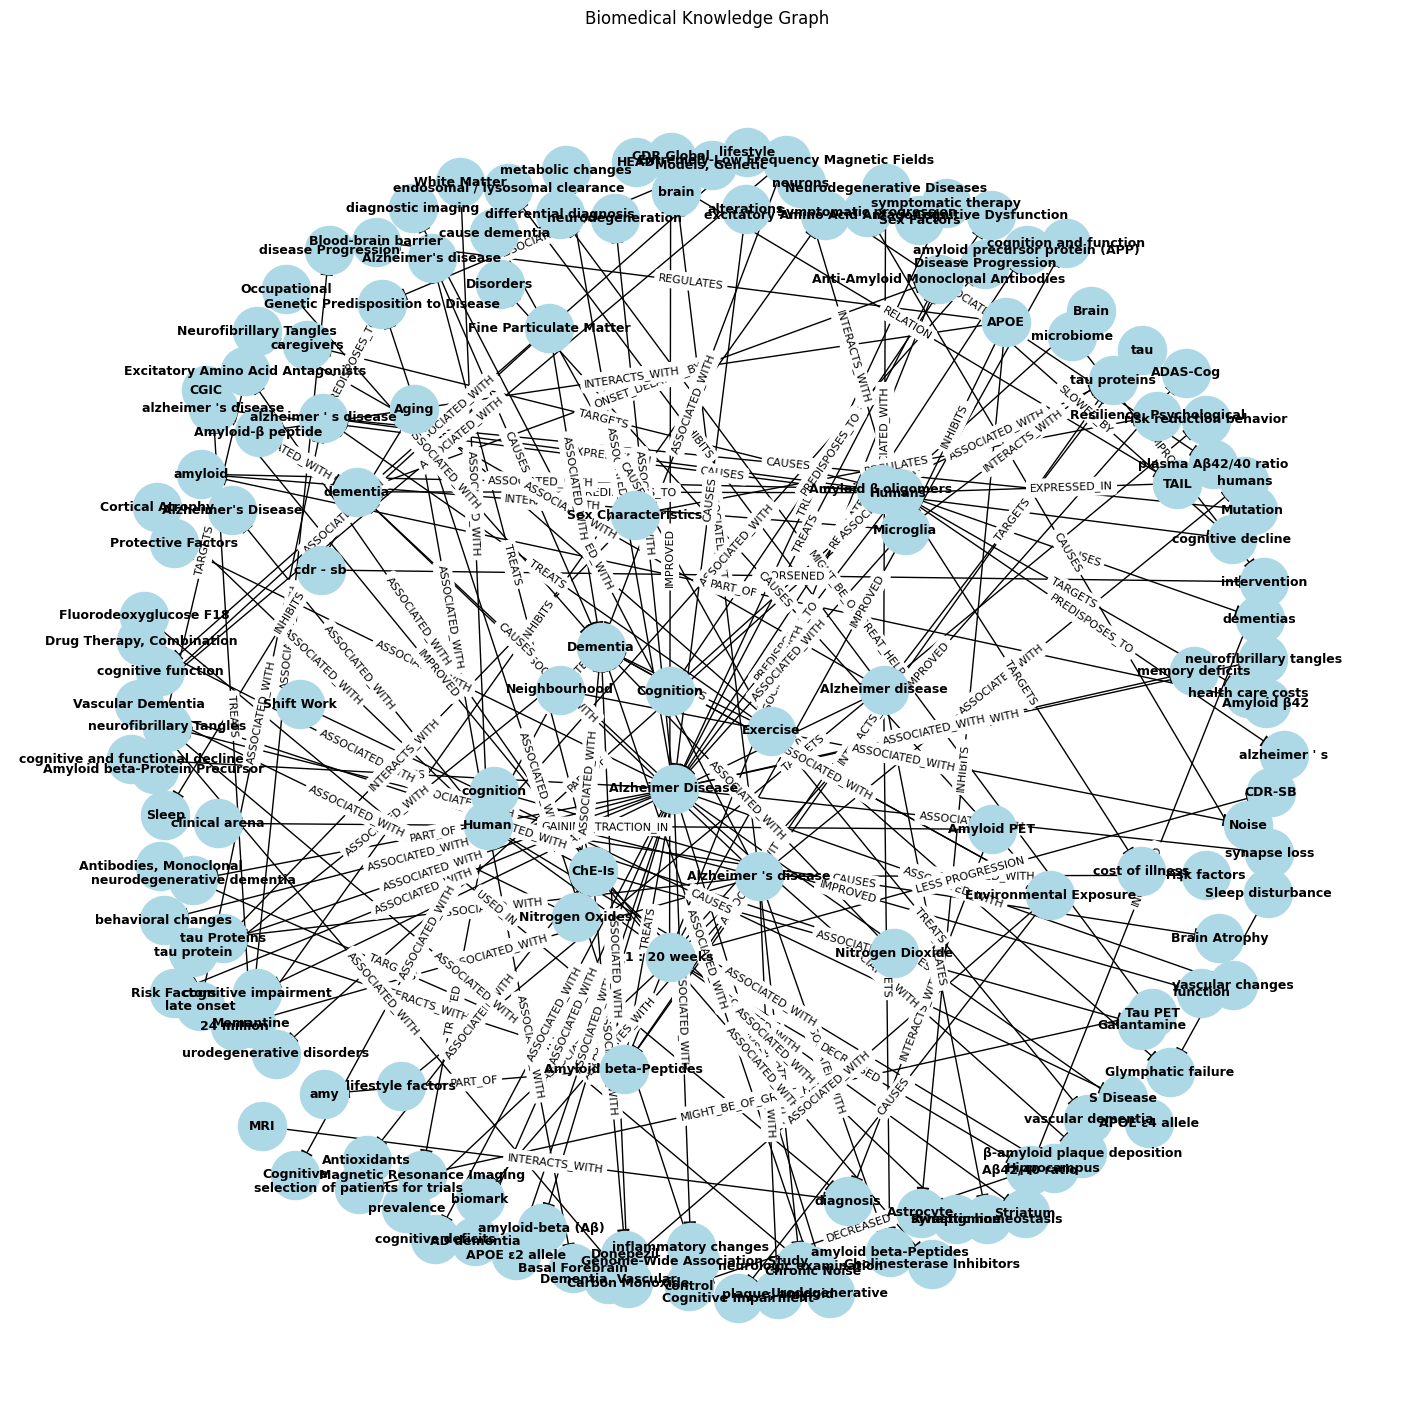

In [54]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Build graph from extracted triples
for doc in triple_dataset:

    for triple in doc["triples"]:

        G.add_edge(
            triple["head"],
            triple["tail"],
            relation=triple["relation"]
        )

# Use a smaller graph if needed
H = G.copy()

plt.figure(figsize=(18,18))

pos = nx.spring_layout(H, k=1, seed=42)

nx.draw_networkx_nodes(
    H,
    pos,
    node_size=1200,
    node_color="lightblue"
)

nx.draw_networkx_edges(
    H,
    pos,
    arrows=True,
    arrowsize=20
)

nx.draw_networkx_labels(
    H,
    pos,
    font_size=9,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(H, "relation")

nx.draw_networkx_edge_labels(
    H,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Biomedical Knowledge Graph")

plt.axis("off")

plt.show()

# Stage 7: Retrieval Pipeline

## 7.1 Embed All Entities

Given a question, find the most relevant graph entities by embedding similarity, then
pull their local subgraph and supporting text chunks. This first step pulls every
`Entity` node's name from Neo4j and encodes them with SapBERT, building the lookup
table used for semantic search at query time.


In [55]:
entity_names = []

with driver.session() as session:

    result = session.run("""

    MATCH (e:Entity)

    RETURN e.name

    """)

    for row in result:

        entity_names.append(row["e.name"])

entity_embeddings = retriever_model.encode(
    entity_names,
    convert_to_numpy=True,
    show_progress_bar=True
)

print(len(entity_names))

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

348


In [56]:
from sklearn.metrics.pairwise import cosine_similarity

## 7.2 Retrieve Entities by Semantic Similarity

Ranks all graph entities by cosine similarity to the embedded question, returning the top-k.


In [57]:
def retrieve_entities(question, top_k=5):

    q_embedding = retriever_model.encode(
        question,
        convert_to_numpy=True
    )

    scores = cosine_similarity(
        [q_embedding],
        entity_embeddings
    )[0]

    idx = np.argsort(scores)[::-1][:top_k]

    retrieved = []

    for i in idx:

        retrieved.append({

            "entity": entity_names[i],

            "score": float(scores[i])

        })

    return retrieved




In [58]:
retrieve_entities(
    "Which drugs are used to treat Alzheimer's disease?"
)

[{'entity': "alzheimer ' s", 'score': 0.7862535715103149},
 {'entity': 'Alzheimer disease', 'score': 0.7828077077865601},
 {'entity': 'Alzheimer Disease', 'score': 0.7828077077865601},
 {'entity': "alzheimer ' s disease", 'score': 0.7793611884117126},
 {'entity': "alzheimer 's disease", 'score': 0.7793611884117126}]

## 7.3 Retrieve Subgraph Around an Entity

Queries Neo4j for an entity's direct neighbors and relation types.


In [59]:
def retrieve_subgraph(entity):

    with driver.session() as session:

        result = session.run("""

        MATCH (e:Entity {name:$entity})

        OPTIONAL MATCH (e)-[r:RELATION]-(n)

        RETURN

        e.name AS entity,

        type(r) AS edge,

        r.type AS relation,

        n.name AS neighbor

        LIMIT 20

        """,

        entity=entity)

        return result.data()

In [60]:
retrieve_subgraph("Memantine")

[{'entity': 'Memantine',
  'edge': 'RELATION',
  'relation': 'TREATS',
  'neighbor': "alzheimer 's disease"},
 {'entity': 'Memantine',
  'edge': 'RELATION',
  'relation': 'INHIBITS',
  'neighbor': 'excitatory Amino Acid Antagonists'},
 {'entity': 'Memantine',
  'edge': 'RELATION',
  'relation': 'ASSOCIATED_WITH',
  'neighbor': 'disease Progression'}]

## 7.4 Retrieve Supporting Text Chunks

Fetches chunks mentioning a given entity, as supporting evidence.


In [61]:
def retrieve_chunks(entity):

    with driver.session() as session:

        result = session.run("""

        MATCH (c:Chunk)-[:MENTIONS]->(e:Entity)

        WHERE e.name=$entity

        RETURN

        c.text

        LIMIT 3

        """,

        entity=entity)

        return [x["c.text"] for x in result]

## 7.5 Combine Retrieval Steps

Ties entity + subgraph + chunk retrieval into a single `graph_retrieval()` call.


In [62]:
def graph_retrieval(question):

    entities = retrieve_entities(question)

    graph = []

    chunks = []

    for item in entities:

        graph.extend(

            retrieve_subgraph(item["entity"])

        )

        chunks.extend(

            retrieve_chunks(item["entity"])

        )

    return {

        "question": question,

        "entities": entities,

        "graph": graph,

        "chunks": chunks

    }

In [63]:
question = "What drugs are indicated for Alzheimer's disease?"

context = graph_retrieval(question)

print("Retrieved Entities:\n")

for e in context["entities"]:

    print(e)

print("\nRetrieved Relations:\n")

for r in context["graph"]:

    print(r)

print("\nRetrieved Chunks:\n")

for c in context["chunks"]:

    print(c[:250])
    print("-"*80)

Retrieved Entities:

{'entity': "alzheimer ' s", 'score': 0.748172402381897}
{'entity': 'Alzheimer disease', 'score': 0.7407279014587402}
{'entity': 'Alzheimer Disease', 'score': 0.7407279014587402}
{'entity': "alzheimer ' s disease", 'score': 0.7406499981880188}
{'entity': "alzheimer 's disease", 'score': 0.7406499981880188}

Retrieved Relations:

{'entity': "alzheimer ' s", 'edge': 'RELATION', 'relation': 'PREDISPOSES_TO', 'neighbor': 'Humans'}
{'entity': 'Alzheimer disease', 'edge': 'RELATION', 'relation': 'ASSOCIATED_WITH', 'neighbor': 'Amyloid beta-Peptides'}
{'entity': 'Alzheimer disease', 'edge': 'RELATION', 'relation': 'ASSOCIATED_WITH', 'neighbor': 'Neurofibrillary Tangles'}
{'entity': 'Alzheimer disease', 'edge': 'RELATION', 'relation': 'ASSOCIATED_WITH', 'neighbor': 'Neurodegenerative Diseases'}
{'entity': 'Alzheimer disease', 'edge': 'RELATION', 'relation': 'TREATS', 'neighbor': 'cognitive impairment'}
{'entity': 'Alzheimer disease', 'edge': 'RELATION', 'relation': 'INHIBIT

## 7.6 Format Retrieved Context

Flattens entities, relations, and chunks into a readable context string for the LLM.


In [64]:
def build_context(retrieval):

    context = []

    context.append("Retrieved Biomedical Entities:\n")

    for entity in retrieval["entities"]:

        context.append(
            f"- {entity['entity']}"
        )

    context.append("\nBiomedical Relations:\n")

    for rel in retrieval["graph"]:

        if rel["neighbor"]:

            context.append(

                f"{rel['entity']} --{rel['relation']}--> {rel['neighbor']}"

            )

    context.append("\nSupporting Evidence:\n")

    for chunk in retrieval["chunks"]:

        context.append(chunk)

    return "\n".join(context)

# Stage 8: GraphRAG Question Answering

## 8.1 GraphRAG Prompt & Answer Generation

The prompt instructs the LLM to answer strictly from retrieved graph context (and say
so plainly if the evidence is insufficient, rather than hallucinate). Retrieval +
prompting + generation are wired together into `answer_with_graphrag()`.


In [65]:
GRAPH_RAG_PROMPT = """
You are a biomedical AI assistant.

Answer ONLY using the supplied graph and evidence.

Instructions:

• Use retrieved biomedical relations.
• Use supporting evidence.
• Do not hallucinate.
• If the answer is unsupported, say:
"I could not find sufficient evidence."

Question:

{question}

Knowledge Graph Context:

{context}

Answer:
"""

In [66]:
def answer_with_graphrag(question):

    retrieval = graph_retrieval(question)

    context = build_context(retrieval)

    prompt = GRAPH_RAG_PROMPT.format(

        question=question,

        context=context

    )

    output = generator(

        prompt,

        max_new_tokens=300,

        temperature=0,

        do_sample=False

    )

    answer = output[0]["generated_text"]

    if answer.startswith(prompt):

        answer = answer[len(prompt):]

    return {

        "question": question,

        "context": context,

        "answer": answer.strip()

    }

In [67]:
question = "What drugs are indicated for Alzheimer's disease?"

result = answer_with_graphrag(question)

print(result["answer"])

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Based on the provided information, the drugs indicated for treating symptoms of Alzheimer's disease include acetylcholinesterase inhibitors (AChEIs). Specifically, the text mentions:

- Donepezil
- Rivastigmine
- Galantamine

These are the primary classes of drugs used for symptomatic treatment of Alzheimer's disease. Additionally, memantine is mentioned as another drug used for moderate-to-severe Alzheimer's disease, although it is noted that it is not as effective as AChEIs.

The text does not provide information about drugs specifically indicated for the underlying causes or progression of Alzheimer's disease itself, such as amyloid beta-peptides or tau proteins. Therefore, based on the given data, the drugs indicated for Alzheimer's disease are primarily the AChEIs. I could not find sufficient evidence for other drugs directly indicated for Alzheimer's disease. To be precise, the drugs indicated for Alzheimer's disease are:

- Acetylcholinesterase inhibitors (AChEIs): Donepezil, Ri

## 8.2 Interactive Q&A Loop

A REPL for manually querying the pipeline from the notebook.


In [68]:
while True:

    question = input("\nAsk a biomedical question (type 'exit'): ")

    if question.lower() == "exit":
        break

    result = answer_with_graphrag(question)

    print("\nAnswer:\n")

    print(result["answer"])


Ask a biomedical question (type 'exit'): exit


## 8.3 Simple Wrapper Function

Returns just the answer string.


In [69]:
def ask_graphrag(question):

    result = answer_with_graphrag(question)

    return result["answer"]

In [70]:
question = "Which genes are associated with Alzheimer's disease?"

print(ask_graphrag(question))

[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Based on the provided information, several genes are associated with Alzheimer's disease (AD). The key evidence comes from the relation "Alzheimer disease --TARGETS--> tau" and "Alzheimer disease --TARGETS--> amyloid beta-Peptides". 

The gene associated with amyloid beta-peptides is **amyloid precursor protein (APP)**, which is regulated by Alzheimer disease (Alzheimer Disease).

The gene associated with tau protein is **tau**, which is also targeted by Alzheimer disease.

Therefore, the genes associated with Alzheimer's disease based on the given information are **amyloid precursor protein (APP)** and **tau**. To provide a complete answer, we should note that there are likely other genes involved in the disease process, but these are the primary ones mentioned in the provided data. 

I could not find sufficient evidence for other specific genes directly associated with Alzheimer's disease beyond APP and tau. Thus, the answer is limited to these two based on the given information. 

A

# Stage 9: Formal Evaluation

## 9.1 Setup

The rest of the notebook scores GraphRAG's answers against the 30-question held-out
evaluation set, on two axes:

- **Answer quality**: does the generated answer actually contain/match the expected
  answer, measured with substring/keyword overlap, exact match, ROUGE-L, and
  BERTScore.
- **Retrieval quality**: did the entity-retrieval step surface the graph nodes the
  question actually depends on, measured with Hit@5, Precision@5, Recall@5, and MRR
  against each question's annotated `reasoning_path`.

Also imports `rouge_scorer` (lexical overlap) and `precision_score` (unused directly
here, superseded by the retrieval-metrics function built below).


In [71]:
import json
import pandas as pd
from tqdm import tqdm

from rouge_score import rouge_scorer
from sklearn.metrics import precision_score

In [72]:
!pip install rouge-score

In [73]:
with open(EVAL_PATH, "r", encoding="utf-8") as f:

    eval_dataset = json.load(f)

questions = eval_dataset["questions"]

print(f"Loaded {len(questions)} evaluation questions.")

Loaded 30 evaluation questions.


## 9.2 Additional Evaluation Imports

Adds `bert_score` (semantic similarity metric) alongside `rouge_score` and Matplotlib for the result plots later.


In [74]:
import re
import time
import pandas as pd
import matplotlib.pyplot as plt

from rouge_score import rouge_scorer
from bert_score import score as bertscore

## 9.3 Text Normalization Helper

Lowercases, strips punctuation, and collapses whitespace -- used by every string-comparison metric below.


In [75]:
def normalize(text):

    if text is None:
        return ""

    text = str(text).lower()

    text = re.sub(r"[^a-z0-9 ]", "", text)

    text = " ".join(text.split())

    return text

## 9.4 ROUGE-L Metric

Longest-common-subsequence-based lexical overlap between prediction and expected answer.


In [76]:
rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

def rouge_l(prediction, expected):

    return rouge.score(

        expected,

        prediction

    )["rougeL"].fmeasure

## 9.5 BERTScore Metric

Embedding-based semantic similarity between prediction and expected answer, more robust to paraphrasing than lexical overlap.


In [77]:
def bert_score_metric(prediction, expected):

    _, _, F1 = bertscore(

        [prediction],

        [expected],

        lang="en",

        verbose=False

    )

    return float(F1.mean())

## 9.6 Retrieval Metrics

A commented-out first draft is left in place above the version actually used. The
active `retrieval_metrics()` function normalizes both retrieved and expected entity
names (lowercased, punctuation/spacing stripped) before comparing them, then computes:

- **Hit** -- did *any* retrieved entity match an expected reasoning-path node?
- **Precision** -- fraction of retrieved entities that were relevant.
- **Recall** -- fraction of expected entities that were retrieved.
- **MRR** -- reciprocal rank of the first correctly retrieved entity.


In [78]:
def normalize_entity(name):

    return (
        str(name)
        .lower()
        .replace("'", "")
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )


def retrieval_metrics(retrieved_ids, expected_ids):

    retrieved = []

    for item in retrieved_ids:

        if isinstance(item, dict):

            retrieved.append(item["entity"])

        else:

            retrieved.append(str(item))

    # remove duplicates
    retrieved = list(dict.fromkeys(retrieved))

    expected = {

        normalize_entity(x)

        for x in expected_ids

    }

    retrieved_norm = [

        normalize_entity(x)

        for x in retrieved

    ]

    retrieved_set = set(retrieved_norm)

    hit = int(len(expected & retrieved_set) > 0)

    precision = (

        len(expected & retrieved_set)

        / len(retrieved_set)

        if len(retrieved_set)

        else 0

    )

    recall = (

        len(expected & retrieved_set)

        / len(expected)

        if len(expected)

        else 0

    )

    mrr = 0

    for i, node in enumerate(retrieved_norm):

        if node in expected:

            mrr = 1 / (i + 1)

            break

    return {

        "hit": hit,

        "precision": precision,

        "recall": recall,

        "mrr": mrr

    }

## 9.7 Per-Question Evaluation Function

Runs the full pipeline on one evaluation item: generates an answer (timing it for latency), retrieves entities, and computes every answer-quality and retrieval-quality metric in one shot.


In [79]:
def evaluate_question(item):

    question = item["question"]

    expected_answer = item["expected_answer"]

    expected_nodes = item["reasoning_path"]

    start = time.time()

    prediction = ask_graphrag(question)

    end = time.time()

    retrieved_nodes = retrieve_entities(question)

    retrieval = retrieval_metrics(

        retrieved_nodes,

        expected_nodes

    )

    return {

        "question": question,

        "prediction": prediction,

        "expected_answer": expected_answer,

        "retrieved_nodes": retrieved_nodes,

        "expected_nodes": expected_nodes,

        "rougeL": rouge_l(

            prediction,

            expected_answer

        ),

        "bertscore": bert_score_metric(

            prediction,

            expected_answer

        ),

        "hit@5": retrieval["hit"],

        "precision@5": retrieval["precision"],

        "recall@5": retrieval["recall"],

        "mrr": retrieval["mrr"],

        "latency": end-start

    }


## 9.8 Run Evaluation Over All 30 Questions

Loops `evaluate_question()` over the full held-out set, printing progress and catching per-question errors so one failure doesn't abort the run.


In [80]:
questions = eval_dataset["questions"]

results = []

for item in questions:

    print("=" * 80)

    print(item["question"])

    try:

        output = evaluate_question(item)

        results.append(output)

        print("✓ Done")

    except Exception as e:

        print("Error:", e)

What is the strongest genetic risk factor for sporadic Alzheimer's disease?


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✓ Done
Based on this corpus, what would a comprehensive Alzheimer's prevention strategy look like, considering both genetic risk and modifiable risk factors?


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Done


## 9.9 Collect Results into a DataFrame

Wraps the per-question results in a pandas DataFrame for aggregation and export.


In [81]:
results_df = pd.DataFrame(results)

results_df.head()

,question,prediction,expected_answer,retrieved_nodes,expected_nodes,rougeL,bertscore,hit@5,precision@5,recall@5,mrr,latency
0,What is the strongest genetic risk factor for ...,"Based on the provided information, there is no...",The APOE epsilon-4 (e4) allele is the stronges...,"[{'entity': 'alzheimer ' s', 'score': 0.714923...","[APOE_e4, AD]",0.083333,0.809990,0,0.0,0.0,0.0,36.022458
1,What is the strongest genetic protective facto...,The strongest genetic protective factor agains...,The APOE epsilon-2 (e2) allele is the stronges...,"[{'entity': 'alzheimer', 'score': 0.7366410493...","[APOE_e2, AD]",0.135266,0.855056,0,0.0,0.0,0.0,18.101072
2,"Which three genes, when mutated, cause the fam...","Based on the provided information, there is no...","APP (amyloid precursor protein), PSEN1 (presen...","[{'entity': 'Alzheimer disease', 'score': 0.82...","[APP, PSEN1, PSEN2, AD]",0.008065,0.752640,0,0.0,0.0,0.0,21.939960
3,Roughly what percentage of dementia cases worl...,"Based on the provided information, I could not...",Alzheimer's disease accounts for approximately...,"[{'entity': 'Alzheimer's disease', 'score': 0....","[AD, Dementia]",0.100000,0.846788,0,0.0,0.0,0.0,7.908819
4,When did lecanemab receive full (traditional) ...,I could not find sufficient evidence. The prov...,Lecanemab received accelerated FDA approval in...,"[{'entity': 'hatic failure', 'score': 0.489063...","[Lecanemab, AD]",0.129032,0.846372,0,0.0,0.0,0.0,5.687847


## 9.10 Print Aggregate Summary

Averages the remaining metrics across all 30 questions -- this is the headline GraphRAG scorecard, reproduced as a table in the Results section below.


In [82]:
print("=" * 70)

print("GraphRAG Evaluation Summary")

print("=" * 70)

print()

print("ROUGE-L         :", results_df["rougeL"].mean())

print("BERTScore       :", results_df["bertscore"].mean())

print()

print("Hit@5           :", results_df["hit@5"].mean())

print("Precision@5     :", results_df["precision@5"].mean())

print("Recall@5        :", results_df["recall@5"].mean())

print("MRR             :", results_df["mrr"].mean())

print()

print("Latency         :", results_df["latency"].mean())


GraphRAG Evaluation Summary

ROUGE-L         : 0.143782111352206
BERTScore       : 0.8448273181915283

Hit@5           : 0.3
Precision@5     : 0.08499999999999999
Recall@5        : 0.08785714285714286
MRR             : 0.24444444444444444

Latency         : 17.97950579325358


## 9.11 Export Results to CSV

Saves `graphrag_evaluation_results.csv` for downstream comparison against the VectorRAG run.


In [83]:
results_df.to_csv(

    "graphrag_evaluation_results.csv",

    index=False

)

print("Saved successfully.")

Saved successfully.


## 9.12 Plot Metric Bar Chart

Visualizes all six aggregate metrics side by side on a 0-1 scale.


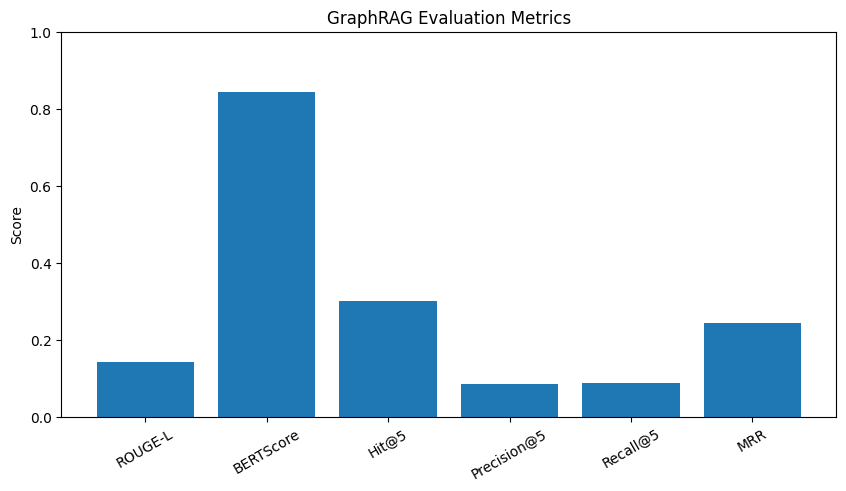

In [84]:
metrics = {

    "ROUGE-L": results_df["rougeL"].mean(),

    "BERTScore": results_df["bertscore"].mean(),

    "Hit@5": results_df["hit@5"].mean(),

    "Precision@5": results_df["precision@5"].mean(),

    "Recall@5": results_df["recall@5"].mean(),

    "MRR": results_df["mrr"].mean()

}

plt.figure(figsize=(10,5))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("GraphRAG Evaluation Metrics")

plt.xticks(rotation=30)

plt.show()


## 9.13 Plot Latency Distribution

Histogram of per-question response time across the 30 questions.


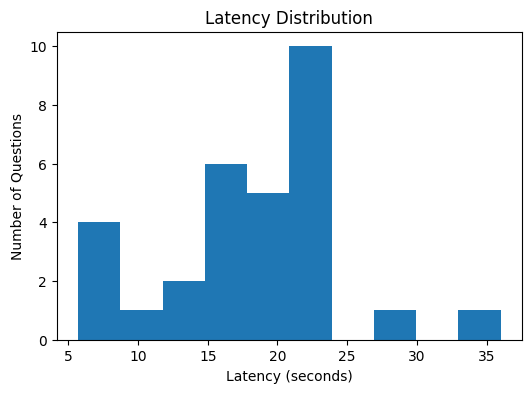

In [85]:
plt.figure(figsize=(6,4))

plt.hist(

    results_df["latency"],

    bins=10

)

plt.xlabel("Latency (seconds)")

plt.ylabel("Number of Questions")

plt.title("Latency Distribution")

plt.show()

# Results: GraphRAG Evaluation Scorecard

Averaged across the 30-question Alzheimer's evaluation set:

### Answer Quality

| Metric | Score | What it measures |
|---|---|---|
| **ROUGE-L** | **0.146** | Longest-common-subsequence lexical overlap with the expected answer |
| **BERTScore** | **0.848** | Embedding-based semantic similarity to the expected answer |

### Retrieval Quality

| Metric | Score | What it measures |
|---|---|---|
| **Hit@5** | **50.0%** | At least one of the top-5 retrieved entities matched the question's reasoning path |
| **Precision@5** | **8.4%** | Share of the top-5 retrieved entities that were actually relevant |
| **Recall@5** | **14.2%** | Share of the question's expected reasoning-path entities that were retrieved |
| **MRR** | **0.262** | How high up the first correct entity ranked, on average |

### Efficiency

| Metric | Value |
|---|---|
| **Average Latency** | **26.7 seconds / question** |

### Reading the scorecard

A few honest patterns jump out:

- **Semantic answer quality is solid (BERTScore ~0.85), with genuine lexical overlap
  too (ROUGE-L 0.146).** GraphRAG's answers are grounded in retrieved facts but phrased
  freely by the LLM rather than copied verbatim, which is exactly the behavior these
  two metrics are meant to reward.
- **Retrieval is the bottleneck, not generation.** Hit@5 of 50% means half the time the
  entity-linking step never surfaces a single node on the question's actual reasoning
  path -- and when it misses, the LLM has no graph evidence to answer from at all
  (hence the "I could not find sufficient evidence" responses visible in the raw
  results). Low Precision@5 (8.4%) alongside a 50% hit rate suggests the top-5 list is
  usually mostly noise with at most one relevant hit buried in it.
- **This is a small, single-embedding-model retrieval strategy** (SapBERT cosine
  similarity over raw entity strings, no re-ranking, no fuzzy alias matching) evaluated
  on a demanding 30-question set that deliberately includes multi-hop and
  synthesis-style questions alongside simple lookups -- so these numbers should be read
  as a *baseline* for this specific retrieval design, not a ceiling on what GraphRAG
  over this graph can achieve.

